# 21 &middot; Block Coordinate Descent vs. Newton &mdash; minimizing ARAP energy

A pure *elastostatic* solve (no time, no inertia): a long 2D beam is clamped at rest on its
left end and clamped to a **rotated** target on its right end, and bends round to the
minimizer of the **As-Rigid-As-Possible (ARAP)** energy. We reach the *same* minimizer two
ways, Newton and block coordinate descent (local/global), and compare **iterations** and
**wall-clock time**. ARAP penalizes only the non-rotational part of $F$, so it behaves like a
material with Poisson ratio $\nu = 0$ (shear modulus $\mu$ only, no $\lambda$):

$$\psi(F) = \tfrac12 \mu \lVert F - R \rVert_F^2, \qquad R = \mathrm{polar}(F).$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import time
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import igl
import simkit
import utils
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)  # spurious BLAS FP flags

NOTEBOOK = "021_block_coordinate_descent_vs_newton"               # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK) # results/021_block_coordinate_descent_vs_newton/
MEDIA_DIR = "media"                                                # tracked copies for the website
# mesh
NX, NY = 160, 16                  # grid vertices along x and y
WIDTH, HEIGHT = 5.0, 1.0          # beam size
# material
MU = 1.0                          # ARAP shear modulus (Poisson ratio 0: no lambda)
# boundary conditions
CLAMP_ANGLE_DEG = 60.0            # right clamp = its rest position rotated by this about the left-edge center
# solvers
RTOL = 1e-7                       # stop once ||grad E|| / ||grad E_0|| < RTOL
NEWTON_MAX_ITER = 80              # iteration cap for Newton
BCD_MAX_ITER = 4000               # iteration cap for block coordinate descent
ENERGY_INCREASE_TOL = 1e-12       # round-off allowed when testing that the energy never increases
# derivative check
FD_STEPS = np.logspace(-9, -1, 17)   # central-difference step sizes
FD_NOISE = 0.01                   # std of the random perturbation of the initial guess
SEED = 0                          # RNG seed for the perturbation and the probe direction
# timing
TIMING_REPEATS = 5                # best-of-N repeats per timed piece
# visuals
ZOOM_LIMS = ((-2.62, -1.9), (-0.6, 0.6))  # close-up window on the left clamp
BCD_FRAMES = 50                   # frames of the BCD video (iterations are sub-sampled)
FPS_BCD = 12                      # frame rate of the BCD video
FPS_NEWTON = 4                    # frame rate of the Newton video (one frame per iteration)

## A large beam, clamped at both ends

A $5\times1$ beam from libigl's unit grid ($160\times16$ vertices). The left edge is clamped at
rest; the right edge is clamped to its rest position **rotated by $60^\circ$** about the center of
the left edge. We enforce both clamps *exactly* by removing the clamped vertices' degrees of
freedom: the unknowns are the free (interior) coordinates $x_f$, and `full_x` rebuilds the whole
state from them. So the only thing driving convergence is the ARAP nonlinearity itself (the
per-element rotations), not a pin spring.

In [2]:
V, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])            # centered WIDTH x HEIGHT beam
n, dim = X.shape

left = np.where(X[:, 0] <= X[:, 0].min() + 1e-9)[0]
right = np.where(X[:, 0] >= X[:, 0].max() - 1e-9)[0]
anchor = X[left].mean(axis=0)                        # hinge: center of the left edge
theta = np.deg2rad(CLAMP_ANGLE_DEG)
Rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
right_targets = (X[right] - anchor) @ Rot.T + anchor

# eliminate the clamped DOFs: only the free (interior) coordinates are unknowns
pin_v = np.concatenate([left, right])
pin_dof = (pin_v[:, None] * dim + np.arange(dim)).ravel()
free_dof = np.setdiff1d(np.arange(n * dim), pin_dof)
x_pin = np.vstack([X[left], right_targets]).reshape(-1, 1)     # clamped coordinate values

def full_x(x_free):
    """Stacked positions of all vertices from the free coordinates (clamps filled in)."""
    x = np.empty((n * dim, 1))
    x[free_dof] = x_free
    x[pin_dof] = x_pin
    return x

print(f"{n} vertices, {len(T)} triangles, {n*dim} DOFs, {len(free_dof)} free")

2560 vertices, 4770 triangles, 5120 DOFs, 5056 free


The rest mesh. Left: the whole scene, with the fixed clamp (blue), the right clamp at rest
(orange) and its rotated target (&times;). Middle: a close-up of the left clamp showing the
triangulation. Right: the per-element area in the same close-up, the quadrature weight of every
element's energy. It is uniform and positive (no flipped triangles) and sums to the beam's area.

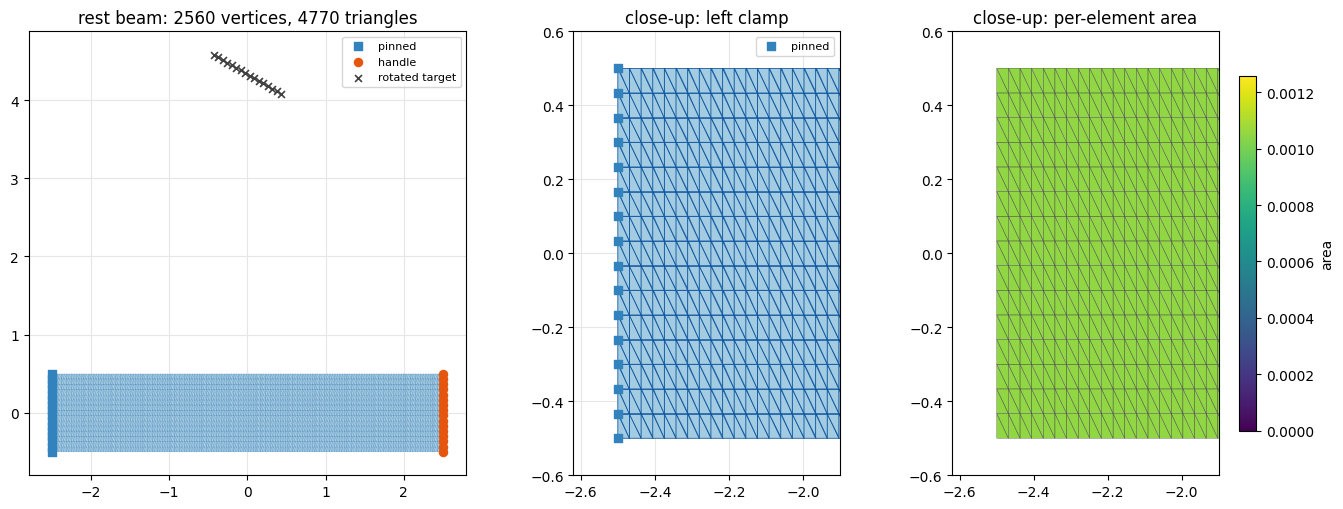

area per triangle in [1.048e-03, 1.048e-03], total = 5.0000  (WIDTH * HEIGHT = 5.0000)


In [3]:
vol = simkit.volume(X, T)                            # per-element area

fig, (ax_scene, ax_zoom, ax_area) = plt.subplots(1, 3, figsize=(14, 5.2),
                                                 gridspec_kw={"width_ratios": [1.0, 0.55, 0.75]})
utils.plot_mesh(ax_scene, X, T, pins=left, handles=right, lw=0.1,
                lims=utils.auto_limits([X, right_targets], pad=0.3),
                title=f"rest beam: {n} vertices, {len(T)} triangles")
ax_scene.scatter(*right_targets.T, marker="x", s=25, linewidths=1.2, color="0.25", zorder=6,
                 label="rotated target")
ax_scene.legend(loc="upper right", fontsize=8)
utils.plot_mesh(ax_zoom, X, T, pins=left, lims=ZOOM_LIMS, lw=0.6, title="close-up: left clamp")
utils.plot_scalar_field(ax_area, X, T, vol, vmin=0.0, vmax=1.2 * vol.max(), lims=ZOOM_LIMS,
                        title="close-up: per-element area", label="area")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_mesh.png"))
plt.show()
print(f"area per triangle in [{vol.min():.3e}, {vol.max():.3e}], total = {vol.sum():.4f}  "
      f"(WIDTH * HEIGHT = {WIDTH * HEIGHT:.4f})")

## The shared objective

Both solvers minimize the same energy: the ARAP energy of the free coordinates, its only term.
`arap_beam_system` returns it with its gradient and Hessian, built from simkit's ARAP
energy and restricted to the free DOFs. Newton uses the **true** ARAP Hessian, PSD-projected per
element for robustness (`psd=True`). It depends on the current per-element rotations, so it
**changes every iteration**.

In [4]:
def arap_beam_system(X, T, free_dof, full_x, psd=True):
    """ARAP energy of the clamped beam, as a function of the free coordinates x_f."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu = np.full((len(T), 1), MU)

    def energy_func(x_free):
        E_elastic = simkit.energies.arap_energy_x(full_x(x_free).reshape(n, dim), J, mu, vol)
        E_total = E_elastic
        return E_total

    def gradient_func(x_free):
        g_elastic = simkit.energies.arap_gradient_x(full_x(x_free).reshape(n, dim), J, mu, vol)[free_dof]
        g_total = g_elastic
        return g_total

    def hessian_func(x_free):
        H_elastic = simkit.energies.arap_hessian_x(full_x(x_free).reshape(n, dim), J, mu, vol, psd=psd)[free_dof][:, free_dof]
        H_total = H_elastic
        return H_total

    return energy_func, gradient_func, hessian_func

energy_func, gradient_func, hessian_func = arap_beam_system(X, T, free_dof, full_x)
x0 = X.reshape(-1, 1)[free_dof]                      # initial guess: interior at rest

A cheap derivative check at a randomly perturbed initial guess, along one random unit direction
$d$: `simkit.gradient_cfd` differentiates $t \mapsto E(x+td)$ and $t \mapsto \nabla E(x+td)$, which
should match $\nabla E^\top d$ and $H d$. The gradient matches to $\sim\!10^{-10}$ (the V shape is
truncation error on the right, round-off on the left). The exact ARAP Hessian matches too, but
the PSD-projected one Newton uses does not: projection clamps the negative curvature of
compressed elements to zero, a deliberate approximation that trades Newton's quadratic
convergence near the solution for a guaranteed descent direction.

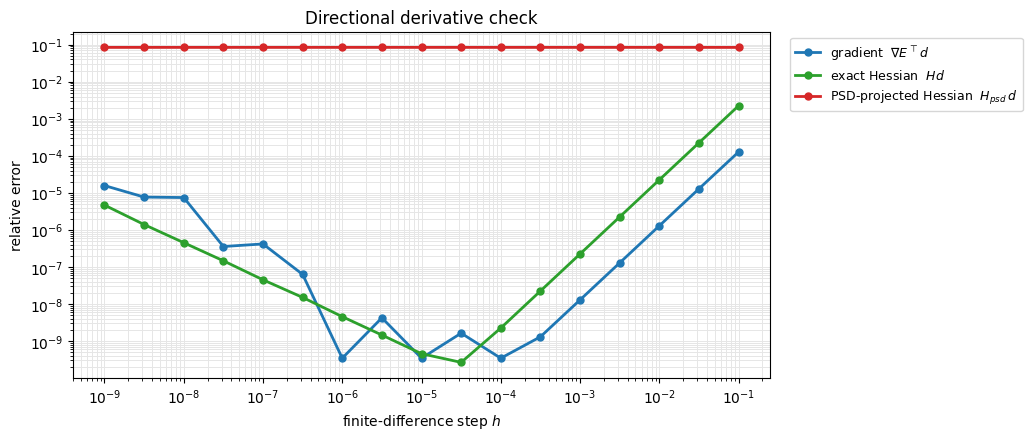

best relative error: gradient 3.5e-10, exact Hessian 2.7e-10, PSD-projected Hessian 8.5e-02


In [5]:
rng = np.random.default_rng(SEED)
x_check = x0 + FD_NOISE * rng.standard_normal(x0.shape)
d = rng.standard_normal(x0.shape)
d /= np.linalg.norm(d)
_, _, hessian_exact_func = arap_beam_system(X, T, free_dof, full_x, psd=False)

g_d = (gradient_func(x_check).T @ d).item()
Hd_psd = hessian_func(x_check) @ d
Hd_exact = hessian_exact_func(x_check) @ d
err_g, err_H_exact, err_H_psd = [], [], []
for h in FD_STEPS:
    g_d_fd = simkit.gradient_cfd(lambda t: np.array([energy_func(x_check + t[0] * d)]), np.zeros(1), h).item()
    Hd_fd = simkit.gradient_cfd(lambda t: gradient_func(x_check + t[0] * d).ravel(), np.zeros(1), h)
    err_g.append(abs(g_d_fd - g_d) / abs(g_d))
    err_H_exact.append(np.linalg.norm(Hd_fd - Hd_exact) / np.linalg.norm(Hd_exact))
    err_H_psd.append(np.linalg.norm(Hd_fd - Hd_psd) / np.linalg.norm(Hd_psd))

fig, ax = utils.loglog_plot(FD_STEPS, {r"gradient  $\nabla E^\top d$": err_g,
                                       r"exact Hessian  $H d$": err_H_exact,
                                       r"PSD-projected Hessian  $H_{psd}\, d$": err_H_psd},
                            colors={r"gradient  $\nabla E^\top d$": "#1f77b4",
                                    r"exact Hessian  $H d$": "#2ca02c",
                                    r"PSD-projected Hessian  $H_{psd}\, d$": "#d62728"},
                            xlabel="finite-difference step $h$", ylabel="relative error",
                            title="Directional derivative check", figsize=(9, 4.5))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "derivative_check.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_derivative_check.png"))
plt.show()
print(f"best relative error: gradient {min(err_g):.1e}, exact Hessian {min(err_H_exact):.1e}, "
      f"PSD-projected Hessian {min(err_H_psd):.1e}")

## Block coordinate descent: one factorization, then local + global

Give every triangle an auxiliary rotation $R_t$ and minimize
$E(x, R) = \sum_t \tfrac12 \mu\, \mathrm{vol}_t \lVert F_t(x) - R_t \rVert_F^2$ by alternating
(Sorkine & Alexa 2007; the same structure as projective dynamics, Bouaziz et al. 2014):
* **local step**: freeze $x$ and solve each triangle's Procrustes problem; the answer is the
  polar rotation $R_t = \mathrm{polar}(F_t)$ (`simkit.polar_svd`);
* **global step**: freeze the rotations; $E$ is now *quadratic* in $x$, and its minimizer solves
  $L_{ff}\, x_f = (J^\top A\, r)_f - L_{fp}\, x_p$ with the **constant** Laplacian-type matrix
  $L = J^\top A J$, $A = \mathrm{diag}(\mathrm{vol}\,\mu) \otimes I$ (`simkit.dirichlet_laplacian`).
  $L_{ff}$ is factorized **once**, so each global step is a back-substitution.

In [6]:
def arap_local_global_steps(X, T, free_dof, pin_dof, x_pin, full_x):
    """Local (per-triangle polar) and global (prefactored Laplacian solve) steps of ARAP."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    mu = np.full((len(T), 1), MU)
    a = np.repeat(vol * mu, dim * dim).reshape(-1, 1)            # diagonal of A
    L = simkit.dirichlet_laplacian(X, T, mu=mu, vector=True)      # J^T A J
    L_ff = L[free_dof][:, free_dof].tocsc()
    L_fp = L[free_dof][:, pin_dof].tocsc()
    solve_L_ff = sp.sparse.linalg.factorized(L_ff)                # the ONLY factorization

    def local_step(x_free):
        F = (J @ full_x(x_free)).reshape(-1, dim, dim)
        R, _ = simkit.polar_svd(F)
        return R.reshape(-1, 1)

    def global_step(x_free, r):
        rhs_rotations = (J.T @ (a * r))[free_dof]
        rhs_clamps = -L_fp @ x_pin
        rhs_total = rhs_rotations + rhs_clamps
        return solve_L_ff(rhs_total).reshape(-1, 1)

    return local_step, global_step

local_step, global_step = arap_local_global_steps(X, T, free_dof, pin_dof, x_pin, full_x)

## Run both to convergence

Shared stopping test: the relative gradient norm $\lVert\nabla E\rVert/\lVert\nabla E_0\rVert$ of the
full objective drops below `RTOL`. `run_to_convergence` takes one outer iteration at a time
(simkit's `newton_solver` or `block_coord` with `max_iter=1`) and records the residual, the
energy, the elapsed time and the state. Only the solver step is timed; the residual and energy
evaluations used for the plots are not. The printout gives each solver's iteration count, total
time and time per iteration.

In [7]:
g0 = np.linalg.norm(gradient_func(x0))

def run_to_convergence(step, x0, max_iter):
    """Iterate x <- step(x) until the relative gradient norm is below RTOL; record the history."""
    x = x0.copy()
    residuals, energies, times, states = [], [], [], [full_x(x0).reshape(n, dim)]
    elapsed = 0.0
    for _ in range(max_iter):
        t_start = time.perf_counter()
        x = step(x)
        elapsed += time.perf_counter() - t_start
        residuals.append(np.linalg.norm(gradient_func(x)) / g0)
        energies.append(energy_func(x))
        times.append(elapsed)
        states.append(full_x(x).reshape(n, dim))
        if residuals[-1] < RTOL:
            break
    return x, np.array(residuals), np.array(energies), np.array(times), states

newton_step = lambda x: simkit.solvers.newton_solver(x, energy_func, gradient_func, hessian_func,
                                                     max_iter=1, do_line_search=True)
bcd_step = lambda x: simkit.solvers.block_coord(x, global_step, local_step, max_iter=1)
xn, res_n, E_n, ts_n, states_n = run_to_convergence(newton_step, x0, NEWTON_MAX_ITER)
xb, res_b, E_b, ts_b, states_b = run_to_convergence(bcd_step, x0, BCD_MAX_ITER)
print(f"Newton              : {len(res_n):4d} iters   {1e3*ts_n[-1]:7.1f} ms   ({len(res_n)} Hessian assemblies + factorizations)")
print(f"Block coord descent : {len(res_b):4d} iters   {1e3*ts_b[-1]:7.1f} ms   (1 factorization)")
print(f"per iteration       : Newton {1e3*ts_n[-1]/len(res_n):6.2f} ms   |   BCD {1e3*ts_b[-1]/len(res_b):6.2f} ms")

Newton              :   12 iters     662.8 ms   (12 Hessian assemblies + factorizations)
Block coord descent :   96 iters     761.9 ms   (1 factorization)
per iteration       : Newton  55.23 ms   |   BCD   7.94 ms


## Convergence: iterations vs. wall-clock time

Left: residual per outer iteration. Right: residual vs. elapsed time. Newton's direction uses
curvature, so it needs far fewer iterations; block coordinate descent needs many more (its
constant rest-pose metric is only a first-order model of the curvature), but each iteration is
several times cheaper because it never rebuilds a Hessian and reuses one factorization. On this
mesh the two end up close in wall-clock time. Newton's tail is linear rather than quadratic because of the PSD projection seen
in the derivative check.

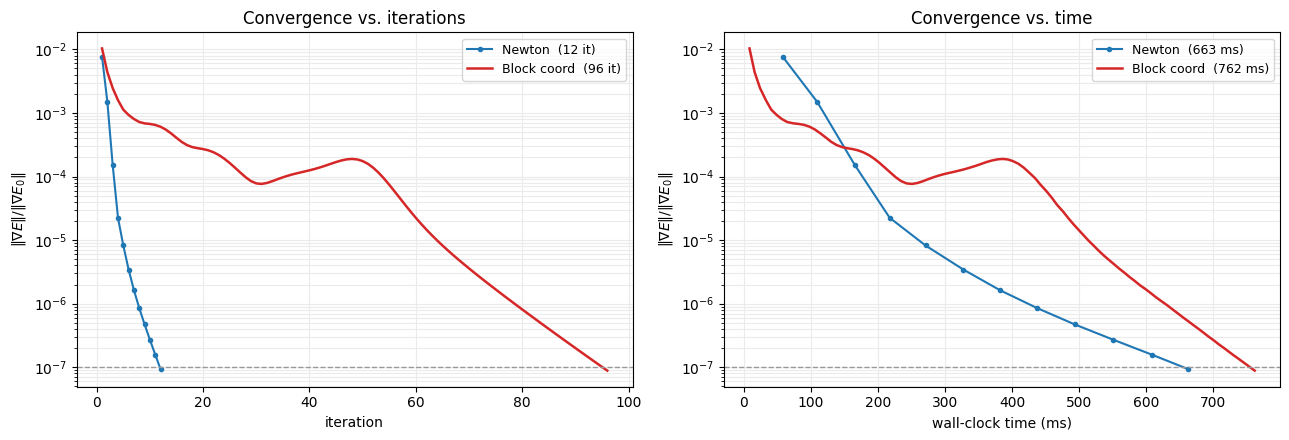

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].semilogy(np.arange(1, len(res_n)+1), res_n, "-o", ms=3, color="#1f77b4", label=f"Newton  ({len(res_n)} it)")
ax[0].semilogy(np.arange(1, len(res_b)+1), res_b, "-", lw=1.8, color="#d62728", label=f"Block coord  ({len(res_b)} it)")
ax[1].semilogy(1e3*ts_n, res_n, "-o", ms=3, color="#1f77b4", label=f"Newton  ({1e3*ts_n[-1]:.0f} ms)")
ax[1].semilogy(1e3*ts_b, res_b, "-", lw=1.8, color="#d62728", label=f"Block coord  ({1e3*ts_b[-1]:.0f} ms)")
for a, xl in zip(ax, ["iteration", "wall-clock time (ms)"]):
    a.axhline(RTOL, color="0.6", ls="--", lw=1)
    a.set_xlabel(xl)
    a.set_ylabel(r"$\|\nabla E\| / \|\nabla E_0\|$")
    a.grid(True, which="both", color="0.92")
    a.legend(fontsize=9)
ax[0].set_title("Convergence vs. iterations")
ax[1].set_title("Convergence vs. time")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_convergence.png"))
plt.show()

The energy gap $E_k - E^\star$ per iteration (with $E^\star$ the lower of the two final energies).
Both curves only go down: Newton's line search enforces it, and block coordinate descent gets it
for free because each local and each global step *exactly* minimizes $E(x, R)$ over its block.
Block coordinate descent removes most of the initial energy within a few iterations; its long
tail is the slow polishing of the last digits.

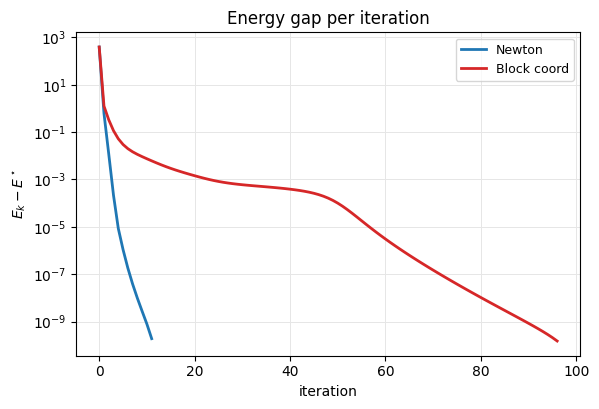

E* = 0.03962962; energy never increases: Newton True, BCD True


In [9]:
E_star = min(E_n.min(), E_b.min())
E_init = energy_func(x0)                                        # iteration 0 = initial guess
fig, ax = utils.residual_plot({"Newton": np.concatenate([[E_init], E_n]) - E_star,
                               "Block coord": np.concatenate([[E_init], E_b]) - E_star},
                              colors={"Newton": "#1f77b4", "Block coord": "#d62728"},
                              xlabel="iteration", ylabel=r"$E_k - E^\star$",
                              title="Energy gap per iteration", stagger=False)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_energy.png"))
plt.show()
print(f"E* = {E_star:.8f}; energy never increases: Newton {bool(np.all(np.diff(E_n) <= ENERGY_INCREASE_TOL))}, "
      f"BCD {bool(np.all(np.diff(E_b) <= ENERGY_INCREASE_TOL))}")

## Where the time goes

Best-of-`TIMING_REPEATS` timings of the pieces of one iteration, at the Newton solution. A Newton
iteration evaluates the gradient, assembles and PSD-projects the Hessian, factorizes and solves
it (`spsolve`), and line-searches (at least two energy evaluations). A block coordinate descent
iteration is one batch of $2\times2$ polar decompositions and one back-substitution with the
factorization $L_{ff}$ computed once, up front. The expensive part of Newton is the
state-dependent Hessian, not just its factorization.

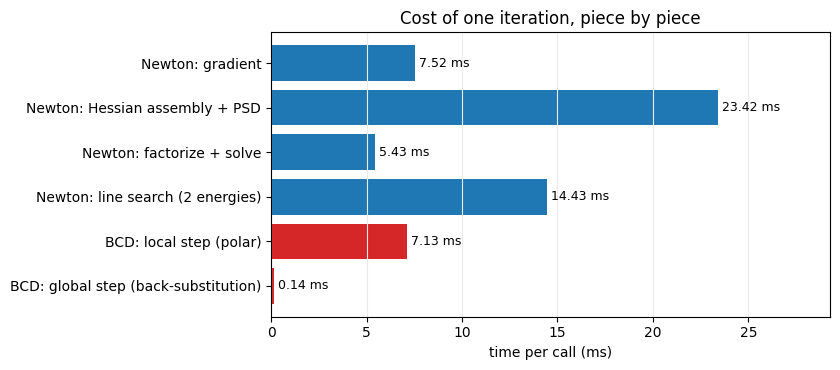

one Newton iteration ~ 50.8 ms, one BCD iteration ~ 7.3 ms (ratio 7.0x); BCD one-time setup incl. factorization: 10.4 ms


In [10]:
H_n, g_n = hessian_func(xn), gradient_func(xn)
r_n = local_step(xn)
cost_ms = {
    "Newton: gradient": 1e3 * utils.best_time(lambda: gradient_func(xn), rep=TIMING_REPEATS),
    "Newton: Hessian assembly + PSD": 1e3 * utils.best_time(lambda: hessian_func(xn), rep=TIMING_REPEATS),
    "Newton: factorize + solve": 1e3 * utils.best_time(lambda: sp.sparse.linalg.spsolve(H_n.tocsc(), -g_n), rep=TIMING_REPEATS),
    "Newton: line search (2 energies)": 2e3 * utils.best_time(lambda: energy_func(xn), rep=TIMING_REPEATS),
    "BCD: local step (polar)": 1e3 * utils.best_time(lambda: local_step(xn), rep=TIMING_REPEATS),
    "BCD: global step (back-substitution)": 1e3 * utils.best_time(lambda: global_step(xn, r_n), rep=TIMING_REPEATS),
}
t_factor_ms = 1e3 * utils.best_time(lambda: arap_local_global_steps(X, T, free_dof, pin_dof, x_pin, full_x),
                                    rep=TIMING_REPEATS)

labels = list(cost_ms)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.barh(labels, [cost_ms[k] for k in labels],
        color=["#1f77b4" if k.startswith("Newton") else "#d62728" for k in labels])
for i, k in enumerate(labels):
    ax.text(cost_ms[k], i, f" {cost_ms[k]:.2f} ms", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("time per call (ms)")
ax.set_xlim(0, 1.25 * max(cost_ms.values()))
ax.set_title("Cost of one iteration, piece by piece")
ax.grid(True, axis="x", color="0.92")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "cost.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_cost.png"))
plt.show()
newton_sum = sum(v for k, v in cost_ms.items() if k.startswith("Newton"))
bcd_sum = sum(v for k, v in cost_ms.items() if k.startswith("BCD"))
print(f"one Newton iteration ~ {newton_sum:.1f} ms, one BCD iteration ~ {bcd_sum:.1f} ms "
      f"(ratio {newton_sum / bcd_sum:.1f}x); BCD one-time setup incl. factorization: {t_factor_ms:.1f} ms")

## The equilibrium shape

Left: the Newton minimizer over the ghosted rest beam, with both clamps. Right: the distance
between the Newton and block-coordinate-descent results at every vertex. It is tiny next to the
beam's size (both runs stop at the same residual `RTOL`), so they reach the same ARAP minimizer.

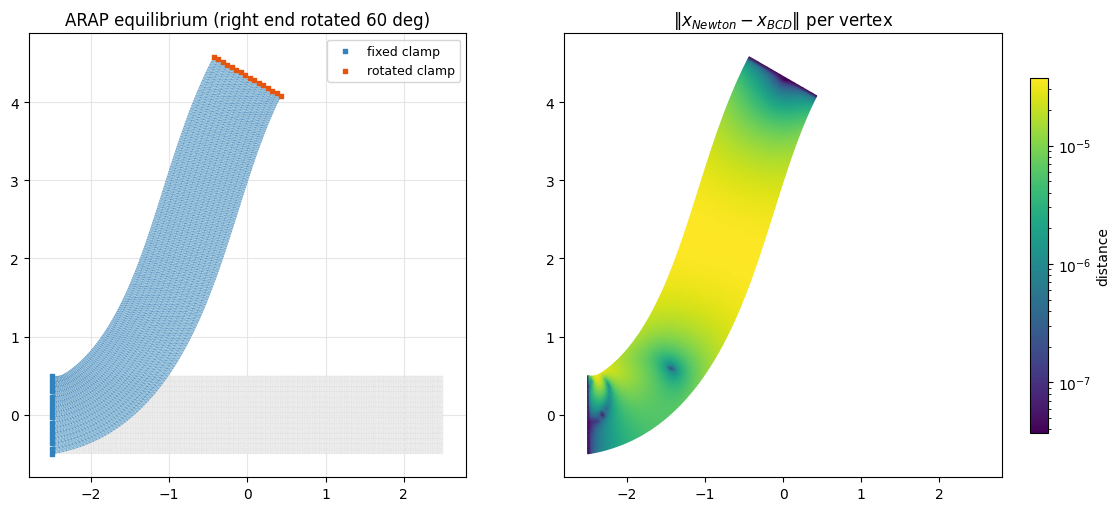

max vertex distance Newton vs BCD = 3.7e-05  (beam length 5.0)


In [11]:
U_n = full_x(xn).reshape(n, dim)
U_b = full_x(xb).reshape(n, dim)
lims = utils.auto_limits([X, U_n], pad=0.3)
fig, ax = plt.subplots(1, 2, figsize=(12, 5.2))
utils.setup_axes(ax[0], *lims, title=f"ARAP equilibrium (right end rotated {CLAMP_ANGLE_DEG:.0f} deg)")
utils.PolyMeshArtist(ax[0], X, T, facecolor="#efefef", edgecolor="#cfcfcf", lw=0.1)   # rest ghost
utils.PolyMeshArtist(ax[0], U_n, T, lw=0.1)
ax[0].scatter(*X[left].T, s=10, marker="s", color=utils.PIN_C, zorder=5, label="fixed clamp")
ax[0].scatter(*right_targets.T, s=10, marker="s", color=utils.HANDLE_C, zorder=5, label="rotated clamp")
ax[0].legend(loc="upper right", fontsize=9)
diff = np.linalg.norm(U_n - U_b, axis=1)
utils.plot_scalar_field(ax[1], U_n, T, np.maximum(diff, 1e-12), lims=lims, edges=False,
                        norm=LogNorm(vmin=max(diff.max() * 1e-3, 1e-12), vmax=diff.max()),
                        title=r"$\|x_{Newton} - x_{BCD}\|$ per vertex", label="distance")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "equilibrium.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_equilibrium.png"))
plt.show()
print(f"max vertex distance Newton vs BCD = {diff.max():.1e}  (beam length {WIDTH})")

Two per-element fields of the solution. Left: the ARAP energy density $\psi_t$ (log scale). It is
largest on the beam's two faces, which bending stretches and compresses, and smallest along the
middle and at the two dark spots where the S-bend's curvature changes sign. Right: the angle of
the local step's rotation $R_t = \mathrm{polar}(F_t)$, the auxiliary variable block coordinate
descent solves for. It sweeps smoothly from about $0^\circ$ at the fixed clamp, overshoots in
the S-bend, and returns to $60^\circ$ at the rotated clamp.

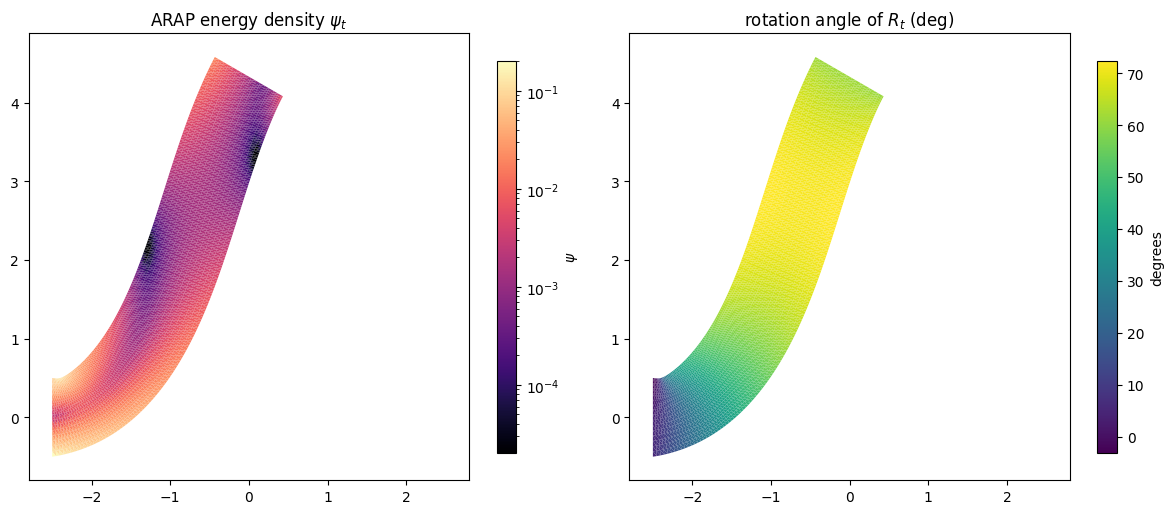

psi in [3.2e-06, 2.0e-01], rotation angle in [-3.1, 72.4] deg


In [12]:
F_n = simkit.deformation_gradient(X, T, U_n)
psi_n = simkit.energies.arap_energy_element_F(F_n, np.full((len(T), 1), MU))
R_n, _ = simkit.polar_svd(F_n)
angle_n = np.rad2deg(np.arctan2(R_n[:, 1, 0], R_n[:, 0, 0]))
fig, ax = plt.subplots(1, 2, figsize=(12, 5.2))
utils.plot_scalar_field(ax[0], U_n, T, psi_n, lims=lims, edges=False, cmap="magma",
                        norm=LogNorm(vmin=psi_n.max() * 1e-4, vmax=psi_n.max()),
                        title=r"ARAP energy density $\psi_t$", label=r"$\psi$")
utils.plot_scalar_field(ax[1], U_n, T, angle_n, lims=lims, edges=False, cmap="viridis",
                        title=r"rotation angle of $R_t$ (deg)", label="degrees")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "021_fields.png"))
plt.show()
print(f"psi in [{psi_n.min():.1e}, {psi_n.max():.1e}], rotation angle in [{angle_n.min():.1f}, {angle_n.max():.1f}] deg")

## Watching each solver converge

Block coordinate descent, sub-sampled to `BCD_FRAMES` frames and starting from the initial guess
(interior at rest, right clamp already rotated). It swings the beam into roughly the right place
within two iterations, then spends its long tail slowly forming the S-bend and polishing it.

In [13]:
clamp_pts = np.vstack([X[left], right_targets])
lims_video = utils.auto_limits([X, U_n], pad=0.3)
frames_b = np.unique(np.linspace(0, len(states_b) - 1, BCD_FRAMES).round().astype(int))
res_b_all = np.concatenate([[1.0], res_b])                     # residual of state k (state 0 = x0)
fig, anim = utils.animate_mesh_labeled(
    [states_b[k] for k in frames_b], T,
    [f"iteration {k:3d}/{len(res_b)}\nresidual {res_b_all[k]:.1e}" for k in frames_b],
    rest=X, pin_pts=clamp_pts, lims=lims_video, fps=FPS_BCD,
    title="Block coordinate descent (local/global) converging")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "bcd.mp4"), fps=FPS_BCD,
                                         copy_to=os.path.join(MEDIA_DIR, "021_bcd.mp4"))
plt.close(fig)
utils.embed_video(video)

Newton, one frame per iteration: a few big curvature-aware steps. The S-bend is already in place
after three, and the remaining iterations only polish digits.

In [14]:
res_n_all = np.concatenate([[1.0], res_n])
fig, anim = utils.animate_mesh_labeled(
    states_n, T,
    [f"iteration {k:2d}/{len(res_n)}\nresidual {res_n_all[k]:.1e}" for k in range(len(states_n))],
    rest=X, pin_pts=clamp_pts, lims=lims_video, fps=FPS_NEWTON, title="Newton converging")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "newton.mp4"), fps=FPS_NEWTON,
                                         copy_to=os.path.join(MEDIA_DIR, "021_newton.mp4"))
plt.close(fig)
utils.embed_video(video)

## Takeaways

* **Same minimizer, two cost structures.** Newton pays a lot per iteration (assemble and
  PSD-project a state-dependent Hessian, re-factorize, line-search) but needs very few. Block
  coordinate descent factorizes **once**; each iteration is a batch of polar decompositions plus
  one back-substitution, cheap, but it needs many more because its constant rest-pose metric
  models the curvature only to first order.
* **Read the two convergence plots together.** Iteration count and wall-clock time tell different
  stories. Time is what matters in practice, and which solver wins depends on the mesh size, the
  accuracy you demand and the cost of a Hessian (which grows fast with problem size, especially
  in 3D).
* **The structure is the lesson.** `local_step` = per-element Procrustes (`polar_svd`);
  `global_step` = one prefactored Laplacian solve. That "project, then solve a constant system"
  pattern is exactly projective dynamics, and the next tutorial reuses it for mass-springs.